In [1]:
import sys

In [2]:
sys.dont_write_bytecode = True

In [3]:
import numpy as np

import matplotlib.pyplot as plt

from IterativeClosestPoint import IterativeClosestPoint

In [4]:
np.random.seed(0)

In [5]:
N = 1000

print(f'Número de Observações: {N}')

Número de Observações: 1000


In [6]:
D = 2

print(f'Dimensão das Observações: {D}')

Dimensão das Observações: 2


In [7]:
Q = np.column_stack(

    (

        x := np.linspace(start = 0, stop = 50, num = N),

        y := 0.2*x*np.sin(0.5*x)

    )

)

print('Nuvem de Pontos Original:\n')

print(Q)

Nuvem de Pontos Original:

[[ 0.00000000e+00  0.00000000e+00]
 [ 5.00500501e-02  2.50474606e-04]
 [ 1.00100100e-01  1.00158472e-03]
 ...
 [ 4.98998999e+01 -1.81411140e+00]
 [ 4.99499499e+01 -1.56955326e+00]
 [ 5.00000000e+01 -1.32351750e+00]]


In [8]:
theta = np.pi/4

print(f'Ângulo de Rotação: {theta:.4f}')

Ângulo de Rotação: 0.7854


In [9]:
R = [

    [np.cos(theta), -np.sin(theta)],

    [np.sin(theta), np.cos(theta)]

]

R = np.array(R)

print('Matriz de Rotação:\n')

print(R)

Matriz de Rotação:

[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


In [10]:
mu = np.array([-2, 5])

print('Vetor de Translação:\n')

print(mu)

Vetor de Translação:

[-2  5]


In [11]:
P = (R @ Q.T + np.expand_dims(mu, axis = 1)).T

np.random.shuffle(P)

print('Nuvem de Pontos Rotacionada:\n')

print(P)

Nuvem de Pontos Rotacionada:

[[35.10491045 38.18107891]
 [25.51424561 38.28702817]
 [ 6.60081176 17.4920632 ]
 ...
 [20.40667326 27.11486482]
 [13.87009281 28.6967431 ]
 [26.98559918 24.42891917]]


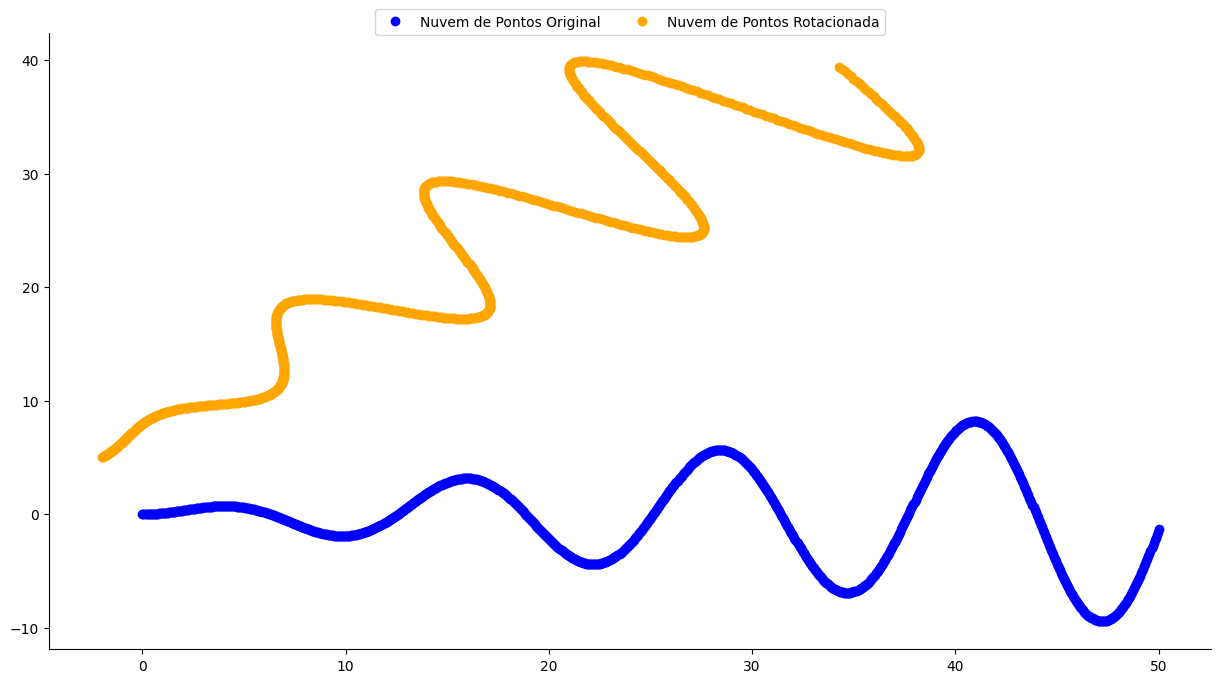

In [12]:
fig = plt.figure(figsize = (15, 8))

ax = fig.add_subplot()

ax.plot(

    Q[:, 0], Q[:, 1],

    marker = 'o', linestyle = 'None',

    color = 'blue', label = 'Nuvem de Pontos Original'

)

ax.plot(

    P[:, 0], P[:, 1],

    marker = 'o', linestyle = 'None',

    color = 'orange', label = 'Nuvem de Pontos Rotacionada'

)

ax.spines['top'].set_visible(False)

ax.spines['right'].set_visible(False)

plt.legend(

    ncols = 3,

    bbox_to_anchor = (0.5, 1.05), loc = 'upper center'

)

plt.show()

In [13]:
ICP = IterativeClosestPoint(Q = Q, P = P)

ICP.update_model()

In [14]:
print('Matriz de Rotação Estimada:\n')

print(ICP.R)

Matriz de Rotação Estimada:

[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


In [15]:
print('Vetor de Translação Estimado:\n')

print(ICP.mu)

Vetor de Translação Estimado:

[-2.  5.]


In [16]:
print('Erro da Estimativa:\n')

print(ICP.epsilon)

Erro da Estimativa:

1.9827583748248855e-14


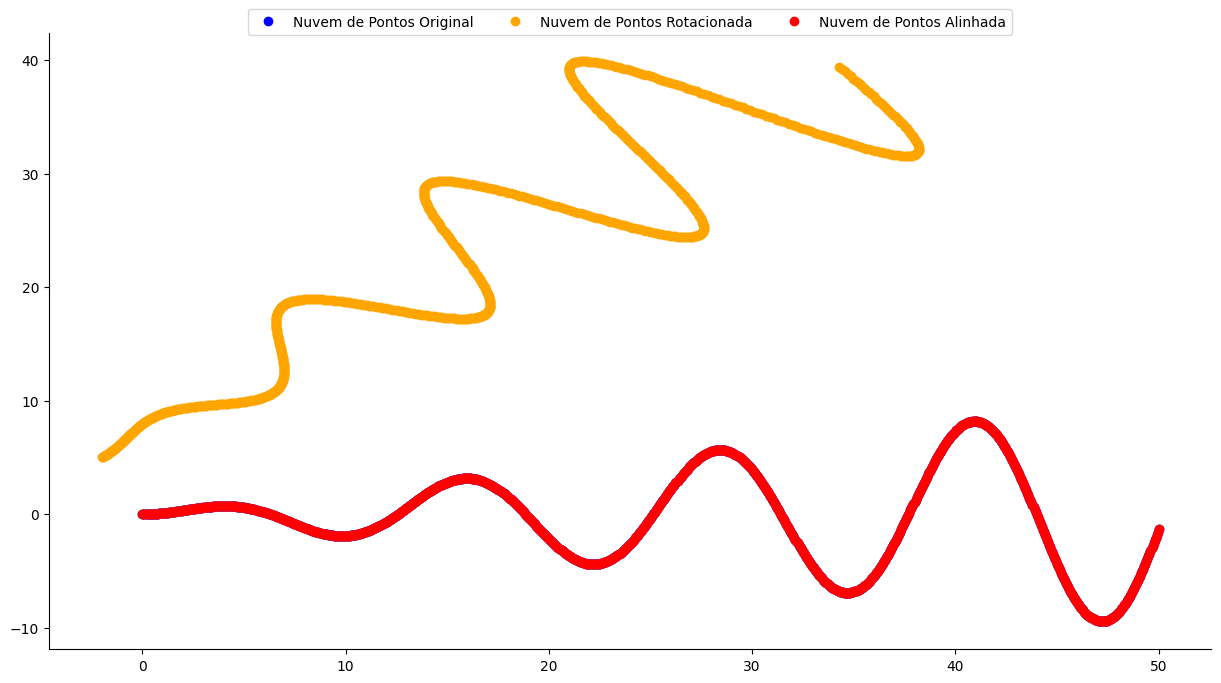

In [17]:
fig = plt.figure(figsize = (15, 8))

ax = fig.add_subplot()

ax.plot(

    ICP.Q[:, 0], ICP.Q[:, 1],
    
    marker = 'o', linestyle = 'None',

    color = 'blue', label = 'Nuvem de Pontos Original'

)

ax.plot(

    ICP.P[:, 0], ICP.P[:, 1],

    marker = 'o', linestyle = 'None',

    color = 'orange', label = 'Nuvem de Pontos Rotacionada'

)

ax.plot(

    ICP.S[:, 0], ICP.S[:, 1],

    marker = 'o', linestyle = 'None',

    color = 'red', label = 'Nuvem de Pontos Alinhada'

)

ax.spines['top'].set_visible(False)

ax.spines['right'].set_visible(False)

plt.legend(

    ncols = 3,

    bbox_to_anchor = (0.5, 1.05), loc = 'upper center'

)

plt.show()